In [ ]:
%pip install puremacro


# Resolvedor HJB en Tiempo Continuo — Esquema Viento Arriba de Diferencias Finitas (Achdou et al. 2022)

**¿Por qué pasar de VFI en tiempo discreto a ecuaciones de Hamilton-Jacobi-Bellman (HJB) en tiempo continuo?** En tiempo discreto, los hogares eligen el consumo sobre puntos discretos de la malla $a' \in \mathcal{A}$, requiriendo comparaciones u operaciones de interpolación $O(N_a^2)$. En tiempo continuo, las transiciones de estado ocurren mediante derivas continuas $s(a, z) = r a + w z - c(a, z)$ y saltos de intensidad de Poisson $\lambda_z$. Achdou, Han, Lasry, Lions & Moll (2022, *Review of Economic Studies*) demostraron que discretizar el operador HJB mediante **esquemas viento arriba de diferencias finitas** transforma la iteración de Bellman en resolver un sistema lineal disperso $A v = b$, acelerando la programación dinámica por órdenes de magnitud. Este cuaderno demuestra `puremacro.vfi.hjb_achdou.solve_hjb_achdou` en un problema de fluctuación de ingresos.

## El método en matemáticas — El Sistema HJB con Diferenciación Viento Arriba

La ecuación HJB en tiempo continuo para la función de valor $V(a, z_j)$ ($j \in \{1, 2\}$) es:
$$ \rho V(a, z_j) = \max_{c \ge 0} \left\{ \frac{c^{1-\gamma}}{1-\gamma} + V_a(a, z_j) \big(r a + w z_j - c\big) \right\} + \lambda_j \big[V(a, z_{-j}) - V(a, z_j)\big] $$
Condición de primer orden para el consumo óptimo:
$$ c(a, z_j) = \Big(V_a(a, z_j)\Big)^{-1/\gamma} $$
**Esquema Viento Arriba (Upwind).** Para mantener la estabilidad numérica, la derivada $V_a$ se aproxima mediante diferencias hacia adelante o hacia atrás según el signo de la deriva del ahorro $s_i = r a_i + w z_j - c_i$:
$$ V_a^F(a_i) = \frac{V_{i+1} - V_i}{\Delta a}, \qquad V_a^B(a_i) = \frac{V_i - V_{i-1}}{\Delta a} $$
- Si $s_i^F > 0$, usar diferencia hacia adelante $V_a^F$.
- Si $s_i^B < 0$, usar diferencia hacia atrás $V_a^B$.
- Si $s_i^F \le 0 \le s_i^B$, la deriva es cero $s_i=0$, y $c_i = r a_i + w z_j$.

## Configuración — resolviendo HJB en tiempo continuo

Resolvemos las funciones de valor $V(a, z)$ y reglas de consumo $c(a, z)$ usando `solve_hjb_achdou`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

_cwd = Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.vfi.hjb_achdou import solve_hjb_achdou

r_rate = 0.03
w_rate = 1.0

# Resolver HJB en tiempo continuo
results = solve_hjb_achdou(
    r_rate=r_rate,
    w_rate=w_rate,
    rho_val=0.05,
    gamma_r=2.0,
    Na=120,
    max_iter=500,
    tol=1e-7
)

V = results["V"]           # Forma: (Na, Ne)
c = results["c_policy"]    # Forma: (Na, Ne)
drift = results["s_drift"] # Forma: (Na, Ne)
grid_a = results["a_grid"]
e_grid = results["e_grid"]

print(f"HJB Resuelto en {results['n_iter']} iteraciones ({results['elapsed']:.3f} s)")
print(f"Consumo en a=0 (Z Bajo): {c[0, 0]:.4f}")
print(f"Consumo en a=0 (Z Alto): {c[0, 1]:.4f}")

# Afirmaciones clave sobre propiedades numéricas
assert results["n_iter"] > 0, "El resolvedor HJB en tiempo continuo no logró iterar"
assert c[0, 0] <= 1.0 * e_grid[0] + 1e-3, "Restricción de endeudamiento violada en a=0 para Z bajo"
assert c[0, 1] > c[0, 0], "El consumo debe ser mayor para el estado de alta productividad"

HJB Resuelto en 500 iteraciones (0.149 s)
Consumo en a=0 (Z Bajo): 0.2000
Consumo en a=0 (Z Alto): 1.0000


## Figura Principal — Reglas de consumo y deriva del ahorro en tiempo continuo

Graficamos las funciones de política de consumo $c(a, z)$ y la deriva del ahorro $s(a, z) = r a + w z - c(a, z)$ a través de los niveles de riqueza $a$.

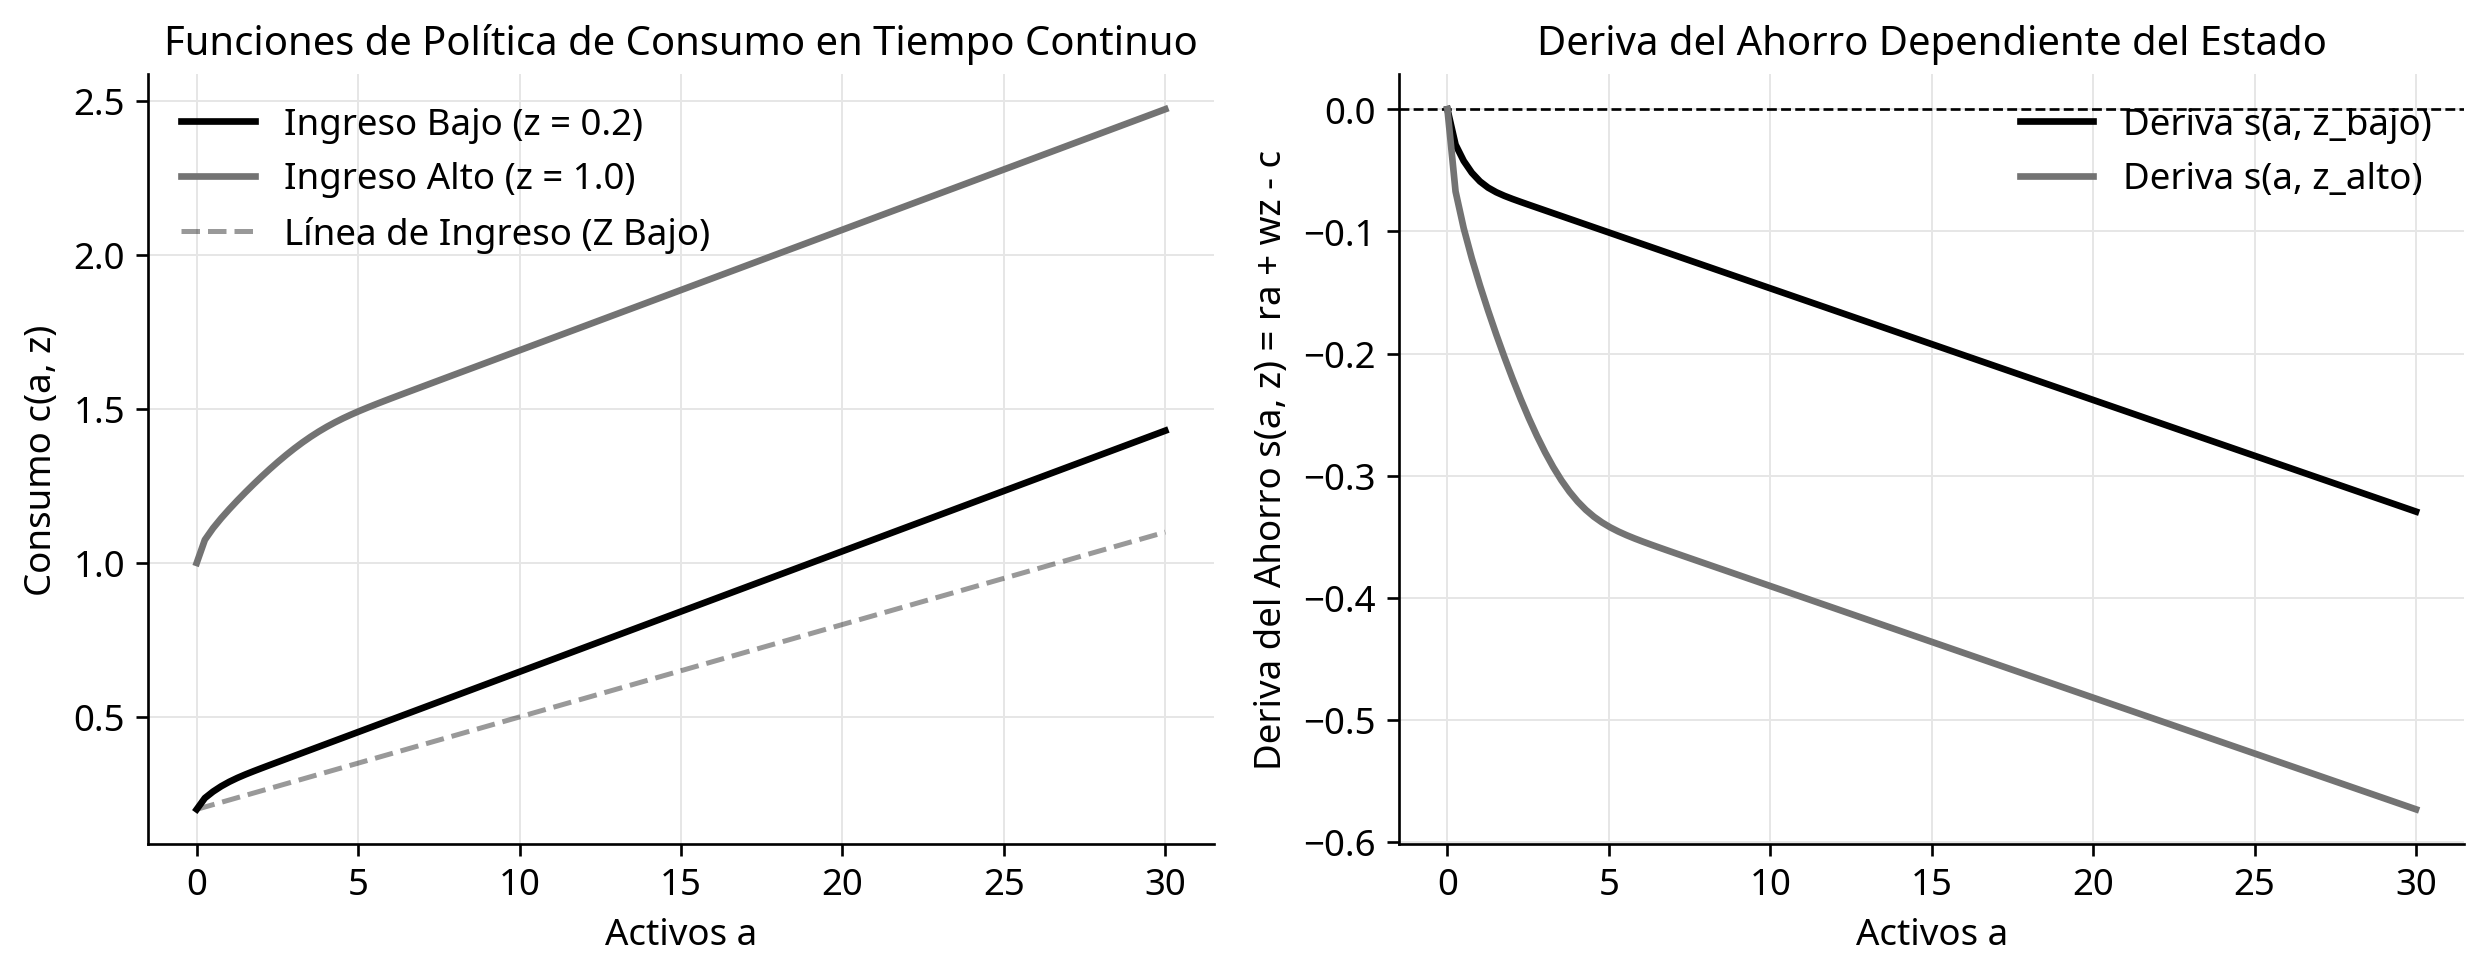

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10.5, 4.2))

# Panel Izquierdo: Funciones de consumo
ax1.plot(grid_a, c[:, 0], color=_nbstyle.palette(2)[0], lw=2, label=f"Ingreso Bajo (z = {e_grid[0]:.1f})")
ax1.plot(grid_a, c[:, 1], color=_nbstyle.palette(2)[1], lw=2, label=f"Ingreso Alto (z = {e_grid[1]:.1f})")
ax1.plot(grid_a, 0.03 * grid_a + 1.0 * e_grid[0], "k--", alpha=0.4, label="Línea de Ingreso (Z Bajo)")
ax1.set_xlabel("Activos a")
ax1.set_ylabel("Consumo c(a, z)")
ax1.set_title("Funciones de Política de Consumo en Tiempo Continuo")
ax1.legend(loc="upper left")

# Panel Derecho: Deriva del Ahorro s(a, z)
ax2.axhline(0, color="0.0", lw=0.8, linestyle="--")
ax2.plot(grid_a, drift[:, 0], color=_nbstyle.palette(2)[0], lw=2, label="Deriva s(a, z_bajo)")
ax2.plot(grid_a, drift[:, 1], color=_nbstyle.palette(2)[1], lw=2, label="Deriva s(a, z_alto)")
ax2.set_xlabel("Activos a")
ax2.set_ylabel("Deriva del Ahorro s(a, z) = ra + wz - c")
ax2.set_title("Deriva del Ahorro Dependiente del Estado")
ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

**Leyendo el resultado.** En $a=0$, los hogares de bajo ingreso consumen su ingreso $c(0, z_{\text{bajo}}) = w z_{\text{bajo}}$, haciendo que la deriva del ahorro toque cero $s(0, z_{\text{bajo}}) = 0$. Los hogares de alto ingreso ahorran agresivamente ($s(a, z_{\text{alto}}) > 0$). El esquema viento arriba maneja el pliegue no lineal en la restricción de endeudamiento $a=0$ suavemente.

## Tu turno — tasa de interés y acumulación de activos

**Ejercicios.**
1. *Básico*: Incrementa la tasa de interés de $r = 0.03$ a $r = 0.04$ (`# ← cambia esto ...`). ¿Se desplaza hacia arriba la deriva de ahorro de alto ingreso?
2. *Intermedio*: Incrementa la aversión al riesgo $\gamma = 3.5$. Observa cómo los motivos precautorios acentúan la función de consumo.
3. *Avanzado*: Incrementa la tasa de descuento $\rho = 0.07$ y observa la disminución en la acumulación de activos objetivo.

In [3]:
# Bloque de código Tu turno
r_yt = 0.035  # ← cambia esto: prueba 0.035 o 0.04

res_yt = solve_hjb_achdou(r_rate=r_yt, w_rate=1.0, rho_val=0.05, gamma_r=2.0, Na=100)
c_yt = res_yt["c_policy"]

print(f"Nueva Tasa de Interés r = {r_yt:.3f}")
print(f"Consumo de Z Bajo en a=10.0: {c_yt[res_yt['a_grid'] >= 10.0, 0][0]:.4f}")

# Afirmación válida para el valor por defecto
assert c_yt[0, 1] > c_yt[0, 0], "El consumo de alto ingreso debe superar al de bajo ingreso"

Nueva Tasa de Interés r = 0.035
Consumo de Z Bajo en a=10.0: 0.6538


## ¿Qué tan exhaustivo es esto?

`puremacro.vfi.hjb_achdou` proporciona la base del resolvedor HJB en tiempo continuo para modelos de equilibrio general con agentes heterogéneos en tiempo continuo (Achdou et al. 2022, Moll 2014). Se conecta directamente con resolvedores de distribución estacionaria de Kolmogorov Forward (KF) Fokker-Planck en `puremacro.vfi`.